# Laboratorio 8 — Desbalance: dónde se remuestrea

Las técnicas de corrección del desbalance ya están escritas y a la vista: ponderar la
pérdida, descartar mayoritarios, generar sintéticos con SMOTE, mover el umbral. Este
laboratorio no las reimplementa. Se ocupa de la pregunta que queda cuando ya se sabe
aplicarlas: **en qué punto del procedimiento corresponde hacerlo**, y qué se paga por
equivocarse.

La respuesta corta es que el remuestreo pertenece **al interior** de la partición: después de
separar los datos de evaluación, nunca antes.

Lo que debemos hacer:

1. Evaluar SMOTE **remuestreando antes de partir**, que es el orden que aparece en mucho
   código publicado.
2. Evaluar la misma estrategia **partiendo antes de remuestrear**, y medir la diferencia.
3. Comparar cuatro estrategias **dentro de la validación cruzada**, que es el protocolo
   correcto, y decidir con la matriz de costos.
4. **Reparar la escala** del modelo remuestreado, y comprobar que ninguna reparación toca
   el ordenamiento.

Hay **cuatro ejercicios** y una recomendación final. Las celdas que
contienen `raise NotImplementedError()` deben completarse; el resto es andamiaje y se ejecuta
sin modificar.

## 0. Preparación

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import (average_precision_score, brier_score_loss,
                             roc_auc_score)

SEMILLA = 42
COSTO_FN = 500.0   # perdida media por fraude no detectado, USD
COSTO_FP = 5.0     # costo de contactar al titular por una alerta falsa, USD

np.set_printoptions(suppress=True)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})

AZUL, TURQUESA, NARANJA = "#19326E", "#50ACB0", "#CD742A"
VIOLETA, OLIVA, GRIS = "#A3477F", "#89A943", "#8A8A8A"

### El caso

**Credit Card Fraud Detection**, de la Université Libre de Bruxelles: 284 807 transacciones
con tarjeta de crédito de titulares europeos, de las cuales **492 son fraudulentas**. La
prevalencia es del $0{,}1727\ \%$ —una transacción fraudulenta cada 577 legítimas— y los
atributos `V1` a `V28` son obtenidos mediante PCA (principal components analysis), de modo que no hay
interpretación posible de los coeficientes (al aplicar PCA se pierde el significado de las variables).

Los costos de los dos errores son distintos y conocidos: un fraude no detectado cuesta
**500 USD** y una alerta falsa, **5 USD**.

In [3]:
#@title Carga del conjunto de datos (ejecutar sin modificar) { display-mode: "form" }
from pathlib import Path

URL = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
CANDIDATAS = [Path("data/creditcard.csv"), Path("../../data/creditcard.csv"),
              Path("creditcard.csv")]

ruta = next((c for c in CANDIDATAS if c.exists()), None)
datos = pd.read_csv(ruta if ruta is not None else URL)
print(f"origen: {ruta if ruta is not None else URL}")

y_todo = datos["Class"].to_numpy()
X_todo = datos.drop(columns=["Class", "Time"]).copy()
X_todo["Amount"] = np.log1p(X_todo["Amount"])     # el monto, en escala logaritmica
X_todo = X_todo.to_numpy()

print(f"n = {len(y_todo):,}   p = {X_todo.shape[1]}   fraudes = {int(y_todo.sum())}")
print(f"prevalencia = {y_todo.mean():.6f} = {100 * y_todo.mean():.4f} %")

origen: https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv
n = 284,807   p = 29   fraudes = 492
prevalencia = 0.001727 = 0.1727 %


### Las funciones de la clase

Las estrategias de corrección ya están implementadas y se entregan tal como se escribieron
durante la exposición. **No corresponde reescribirlas**: el objeto de este laboratorio es
dónde se las llama, no cómo están hechas por dentro.

In [4]:
def ajustar(X, y, **kw):
    """Regresion logistica, la unica familia que se usa en todo el laboratorio."""
    return LogisticRegression(max_iter=3000, random_state=SEMILLA, **kw).fit(X, y)


def submuestrear(X, y, razon=1.0, semilla=SEMILLA):
    """Descarta negativos al azar, sin reemplazo, hasta la razon pedida (min/may)."""
    r = np.random.default_rng(semilla)
    idx_pos = np.flatnonzero(y == 1)
    idx_neg = np.flatnonzero(y == 0)
    elegidos = r.choice(idx_neg, size=min(int(len(idx_pos) / razon), len(idx_neg)),
                        replace=False)
    idx = r.permutation(np.concatenate([idx_pos, elegidos]))
    return X[idx], y[idx]


def smote(X, y, m=5, razon=1.0, semilla=SEMILLA):
    """SMOTE: interpola entre un minoritario y uno de sus m vecinos MINORITARIOS."""
    r = np.random.default_rng(semilla)
    Xp = X[y == 1]
    g = int(np.sum(y == 0) * razon) - len(Xp)          # cuantas generar
    if g <= 0:
        return X.copy(), y.copy()
    _, ind = NearestNeighbors(n_neighbors=m + 1).fit(Xp).kneighbors(Xp)
    ind = ind[:, 1:]                                   # descartar el propio punto
    base = r.integers(0, len(Xp), size=g)
    vecino = ind[base, r.integers(0, m, size=g)]
    lam = r.random((g, 1))                             # lambda ~ U(0,1)
    sinteticos = Xp[base] + lam * (Xp[vecino] - Xp[base])
    Xn = np.vstack([X, sinteticos])
    yn = np.concatenate([y, np.ones(g, dtype=y.dtype)])
    idx = r.permutation(len(yn))
    return Xn[idx], yn[idx]


def precision_en_k(y, s, k=100):
    """Fraccion de fraudes entre las k transacciones de mayor puntaje."""
    return float(np.mean(y[np.argsort(-s)[:k]]))


def costo(y, s, tau):
    """Costo total en USD de operar con umbral tau."""
    predicho = s >= tau
    fn = int(((y == 1) & ~predicho).sum())
    fp = int(((y == 0) & predicho).sum())
    return fn * COSTO_FN + fp * COSTO_FP


TAU = COSTO_FP / (COSTO_FP + COSTO_FN)
print(f"umbral optimo tau* = {COSTO_FP:.0f} / {COSTO_FP + COSTO_FN:.0f} = {TAU:.6f}")

umbral optimo tau* = 5 / 505 = 0.009901


Y una función que resume una evaluación, para que las dos del ejercicio siguiente sean
**comparables línea por línea**: lo único que va a distinguirlas es el orden en que se
remuestrea y se parte.

In [5]:
def metricas(y, s):
    """Las cifras con que se compara cada evaluacion.

    Se informan DOS costos, y la distancia entre ellos es lo que separa un modelo
    que ordena mal de uno que ordena bien pero tiene la escala corrida:

    - `costo en tau*`  : el de operar en el umbral que fija la matriz de costos
    - `costo minimo`   : el mejor alcanzable con ese ordenamiento, barriendo tau
    """
    rejilla = np.unique(np.quantile(s, np.linspace(0, 1, 400)))
    costos = np.array([costo(y, s, t) for t in rejilla])
    i = int(np.argmin(costos))
    return {"AP": average_precision_score(y, s),
            "ROC-AUC": roc_auc_score(y, s),
            "precision@100": precision_en_k(y, s, 100),
            "costo en tau*": costo(y, s, TAU),
            "costo minimo": float(costos[i]),
            "tau minimizador": float(rejilla[i]),
            "prevalencia de prueba": float(y.mean())}


def tabla(filas: dict) -> pd.DataFrame:
    """Arma la tabla comparativa a partir de {etiqueta: dict de metricas}."""
    return pd.DataFrame(filas).T

---

# 1. El número que se reporta

El orden que aparece con frecuencia **erróneamente** en código publicado es: cargar, **balancear**, partir,
ajustar, evaluar. Leído en voz alta suena razonable —«primero se arregla el desbalance y
después se trabaja normalmente»— y produce cifras excelentes.

### Ejercicio 1

Implementar ese orden, exactamente como se lo acaba de describir. El escalador se ajusta
sobre el conjunto de ajuste, que es lo único que este procedimiento sí hace bien.

In [6]:
def evaluar_mal(X, y, semilla=SEMILLA):
    """Remuestrea ANTES de partir. Devuelve las metricas sobre su conjunto de prueba.

    El orden es: SMOTE sobre todo -> particion estratificada 70/30 -> escalado
    ajustado con el conjunto de ajuste -> modelo -> metricas.
    """
    X_rem, y_rem = smote(X, y, razon=1.0, semilla=semilla)
    Xa, Xp, ya, yp = train_test_split(
        X_rem, y_rem, test_size=0.30, random_state=semilla, stratify=y_rem
    )

    escalador = StandardScaler().fit(Xa)
    Xa_std = escalador.transform(Xa)
    Xp_std = escalador.transform(Xp)

    modelo = ajustar(Xa_std, ya)
    puntajes = modelo.predict_proba(Xp_std)[:, 1]
    return metricas(yp, puntajes)


In [7]:
resultado_mal = evaluar_mal(X_todo, y_todo)
for k, v in resultado_mal.items():
    print(f"  {k:24} {v:,.4f}")

  AP                       0.9900
  ROC-AUC                  0.9884
  precision@100            1.0000
  costo en tau*            350,930.0000
  costo minimo             309,980.0000
  tau minimizador          0.0270
  prevalencia de prueba    0.5000


---

# 2. El número correcto

La corrección es de dos líneas: **partir primero**, y aplicar SMOTE únicamente al conjunto de
ajuste. El conjunto de prueba queda como llegó, con su prevalencia real y sin un solo punto
sintético.

### Ejercicio 2

Implementar el orden correcto. Todo lo demás —la semilla, la proporción de la partición, el
escalado, el modelo— es idéntico al ejercicio 1: la única diferencia tiene que ser dónde se
llama a `smote`.

In [8]:
def evaluar_bien(X, y, semilla=SEMILLA):
    """Parte ANTES de remuestrear. Devuelve las metricas sobre prueba intacta.

    El orden es: particion estratificada 70/30 -> escalado ajustado con el conjunto
    de ajuste -> SMOTE SOLO sobre ajuste -> modelo -> metricas sobre prueba.
    """
    Xa, Xp, ya, yp = train_test_split(
        X, y, test_size=0.30, random_state=semilla, stratify=y
    )

    escalador = StandardScaler().fit(Xa)
    Xa_std = escalador.transform(Xa)
    Xp_std = escalador.transform(Xp)

    Xa_rem, ya_rem = smote(Xa_std, ya, razon=1.0, semilla=semilla)
    modelo = ajustar(Xa_rem, ya_rem)
    puntajes = modelo.predict_proba(Xp_std)[:, 1]
    return metricas(yp, puntajes)


In [9]:
# VERIFICACIÓN — la brecha entre lo que se reporta y lo que se entrega
resultado_bien = evaluar_bien(X_todo, y_todo)

comparacion = tabla({"remuestreo antes de partir": resultado_mal,
                     "remuestreo despues de partir": resultado_bien})
print(comparacion.to_string(float_format=lambda v: f"{v:,.4f}"))

optimismo = resultado_mal["AP"] - resultado_bien["AP"]
print(f"\noptimismo en average precision: {optimismo:+.4f} "
      f"({100 * optimismo / resultado_bien['AP']:+.1f} % sobre la cifra honesta)")

# La prueba del primer procedimiento no es el problema original: se le cambio la mezcla
assert resultado_mal["prevalencia de prueba"] > 10 * resultado_bien["prevalencia de prueba"]
print("la prevalencia del conjunto de prueba cambio por un factor de "
      f"{resultado_mal['prevalencia de prueba'] / resultado_bien['prevalencia de prueba']:,.0f}")

                                 AP  ROC-AUC  precision@100  costo en tau*  costo minimo  tau minimizador  prevalencia de prueba
remuestreo antes de partir   0.9900   0.9884         1.0000   350,930.0000  309,980.0000           0.0270                 0.5000
remuestreo despues de partir 0.7048   0.9682         0.8700   270,350.0000   13,465.0000           0.9859                 0.0017

optimismo en average precision: +0.2852 (+40.5 % sobre la cifra honesta)
la prevalencia del conjunto de prueba cambio por un factor de 289


### Para analizar

1. La average precision del primer procedimiento es mucho mayor. **Hay dos causas
   distintas**, y conviene separarlas: una tiene que ver con **qué observaciones** hay en el
   conjunto de prueba, y la otra con **en qué proporción** están. Enunciar cada una.
2. La línea base de la average precision es la prevalencia del conjunto sobre el que se la
   mide. Con ese dato, **¿cuánto de la mejora aparente se explica sin mirar el modelo?**
3. El costo en dólares del primer procedimiento resulta **mayor**, no menor, pese a que
   todas sus métricas de ordenamiento son mejores. **¿Ese número significa algo?** Indicar
   sobre qué población está calculado, cuántos fraudes contiene esa población y si existe.
   La conclusión vale para las dos direcciones: no es una cifra pesimista, es una cifra sin
   referente.
4. `evaluar_mal` ajusta el escalador sobre el conjunto de ajuste, que es lo correcto. **¿Por
   qué eso no alcanza para salvar el procedimiento?**

**Respuesta:**

1. Hay dos fuentes de optimismo. Primero, **contaminación**: al aplicar SMOTE antes de
   partir, algunos sintéticos de prueba se construyen a partir de observaciones reales que
   también influyen en el ajuste (o quedan muy cerca de sintéticos del entrenamiento). La
   prueba deja de ser independiente. Segundo, **cambio de prevalencia**: SMOTE deja las
   clases 1:1 y la partición estratificada conserva aproximadamente 50 % de fraudes en
   prueba, en vez del 0,1727 % real.

2. La línea base de AP pasa de $0{,}001727$ a aproximadamente $0{,}5$. Sin mirar el modelo,
   eso ya supone una suba de unos **0,4983 puntos de AP**, o un factor cercano a **290**.
   Por eso las AP medidas sobre ambas pruebas no son comparables directamente.

3. Ese costo no representa una operación posible. Se calcula sobre el 30 % del conjunto
   balanceado artificialmente: unas **170.589 observaciones**, con aproximadamente
   **85.295 fraudes**, la enorme mayoría sintéticos. No existe una población operativa en
   la que una de cada dos transacciones sea fraudulenta y esos sintéticos sean futuros
   casos reales. Por eso el costo no es optimista ni pesimista: carece de referente.

4. Escalar correctamente evita una fuga adicional, pero no deshace lo ocurrido antes. El
   conjunto de prueba ya cambió de composición y contiene puntos generados usando el
   conjunto completo. Una etapa bien ubicada no puede restaurar la independencia ni la
   prevalencia que SMOTE destruyó al ejecutarse antes de la partición.


---

# 3. La comparación honesta

Una partición única deja la comparación a merced de qué fraudes cayeron de cada lado: son
492 en total, y unos 150 en el conjunto de prueba. La validación cruzada estratificada
promedia sobre $K$ particiones y reduce esa varianza.

La regla del laboratorio se aplica **dentro de cada fold**: se separa el fold de validación,
y recién entonces se escala y se remuestrea con el resto. Un escalador o un SMOTE calculados
antes del bucle contaminarían cada fold de validación con información de sí mismo.

Las cuatro estrategias se declaran con una interfaz común: cada una recibe el conjunto de
ajuste del fold y devuelve **con qué datos ajustar** y **con qué argumentos** construir el
modelo.

In [10]:
ESTRATEGIAS = {
    "sin intervencion": lambda Xa, ya: (Xa, ya, {}),
    "ponderacion":      lambda Xa, ya: (Xa, ya, {"class_weight": "balanced"}),
    "submuestreo 1:1":  lambda Xa, ya: (*submuestrear(Xa, ya), {}),
    "SMOTE 1:1":        lambda Xa, ya: (*smote(Xa, ya), {}),
}
print("estrategias:", ", ".join(ESTRATEGIAS))

estrategias: sin intervencion, ponderacion, submuestreo 1:1, SMOTE 1:1


### Ejercicio 3

Implementar la validación cruzada estratificada respetando el orden. En cada fold: separar,
escalar con el escalador ajustado sobre el conjunto de ajuste, aplicar la estrategia
**solo a ese conjunto**, ajustar y evaluar sobre el fold retenido.

`StratifiedKFold` mantiene la proporción de fraudes en cada fold, lo cual con 492 positivos
no es un lujo: con `KFold` común, algún fold podría quedar casi sin fraudes.

In [11]:
def evaluar_cv(nombre, X, y, K=5):
    """Evalua una estrategia por validacion cruzada estratificada, sin fugas."""
    if nombre not in ESTRATEGIAS:
        raise ValueError(f"estrategia desconocida: {nombre!r}")

    cv = StratifiedKFold(n_splits=K, shuffle=True, random_state=SEMILLA)
    por_fold = []

    for numero, (idx_ajuste, idx_validacion) in enumerate(cv.split(X, y)):
        Xa, ya = X[idx_ajuste], y[idx_ajuste]
        Xv, yv = X[idx_validacion], y[idx_validacion]

        escalador = StandardScaler().fit(Xa)
        Xa_std = escalador.transform(Xa)
        Xv_std = escalador.transform(Xv)

        Xa_modelo, ya_modelo, argumentos = ESTRATEGIAS[nombre](Xa_std, ya)
        modelo = ajustar(Xa_modelo, ya_modelo, **argumentos)
        puntajes = modelo.predict_proba(Xv_std)[:, 1]
        por_fold.append(metricas(yv, puntajes))

    return pd.DataFrame(por_fold).mean().to_dict()


In [12]:
resultados = {nombre: evaluar_cv(nombre, X_todo, y_todo) for nombre in ESTRATEGIAS}
comparativa = tabla(resultados).drop(columns=["prevalencia de prueba"])
print(comparativa.to_string(float_format=lambda v: f"{v:,.4f}"))

print(f"\nmejor average precision:            {comparativa['AP'].idxmax()}")
print(f"menor costo operando en tau*:       {comparativa['costo en tau*'].idxmin()}")
print(f"menor costo con el umbral ajustado: {comparativa['costo minimo'].idxmin()}")

penalidad = comparativa["costo en tau*"] / comparativa["costo minimo"]
print("\ncuanto se paga por operar en tau* con la escala de cada estrategia:")
for nombre, factor in penalidad.sort_values().items():
    print(f"  {nombre:20} x{factor:6.1f}")

                     AP  ROC-AUC  precision@100  costo en tau*  costo minimo  tau minimizador
sin intervencion 0.7584   0.9747         0.7640     7,695.0000    7,419.0000           0.0128
ponderacion      0.7291   0.9773         0.7840   222,368.0000    7,594.0000           0.8056
submuestreo 1:1  0.5186   0.9765         0.6080   227,614.0000    8,463.0000           0.9290
SMOTE 1:1        0.7355   0.9762         0.7860   206,805.0000    7,754.0000           0.8477

mejor average precision:            sin intervencion
menor costo operando en tau*:       sin intervencion
menor costo con el umbral ajustado: sin intervencion

cuanto se paga por operar en tau* con la escala de cada estrategia:
  sin intervencion     x   1.0
  SMOTE 1:1            x  26.7
  submuestreo 1:1      x  26.9
  ponderacion          x  29.3


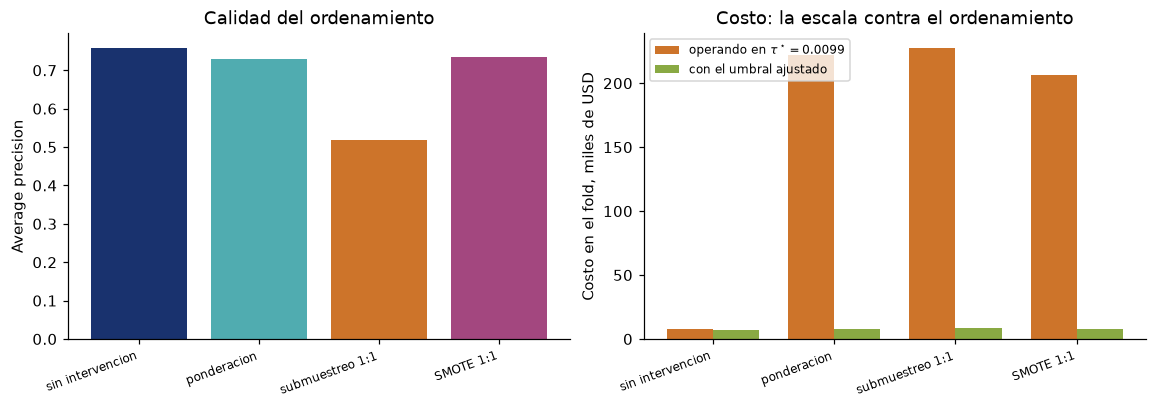

In [13]:
fig, ejes = plt.subplots(1, 2, figsize=(10.4, 3.6), constrained_layout=True)
nombres = list(comparativa.index)
posicion = np.arange(len(nombres))
colores = [AZUL, TURQUESA, NARANJA, VIOLETA]

ejes[0].bar(posicion, comparativa["AP"], color=colores)
ejes[0].set_ylabel("Average precision")
ejes[0].set_title("Calidad del ordenamiento")

ancho = 0.38
ejes[1].bar(posicion - ancho / 2, comparativa["costo en tau*"] / 1000, ancho,
            color=NARANJA, label=rf"operando en $\tau^\star={TAU:.4f}$")
ejes[1].bar(posicion + ancho / 2, comparativa["costo minimo"] / 1000, ancho,
            color=OLIVA, label="con el umbral ajustado")
ejes[1].set_ylabel("Costo en el fold, miles de USD")
ejes[1].set_title("Costo: la escala contra el ordenamiento")
ejes[1].legend(fontsize=8)

for eje in ejes:
    eje.set_xticks(posicion)
    eje.set_xticklabels(nombres, rotation=20, ha="right", fontsize=8)
plt.show()

### HACER

1. Comparar la average precision de `SMOTE 1:1` acá con la del ejercicio 1. **¿Cuál de las
   dos describe lo que el modelo va a hacer con transacciones nuevas?**


**Respuesta:**

La average precision de `SMOTE 1:1` obtenida mediante validación cruzada es la que describe
el desempeño esperado sobre transacciones nuevas. Cada fold de validación queda intacto,
con la prevalencia real, y no participa ni en el escalado, ni en SMOTE, ni en el ajuste.

La AP del ejercicio 1 mide otra tarea: distinguir clases dentro de una muestra artificial
balanceada y contaminada. Aunque resulte mayor, no estima el rendimiento en producción.


---

# 4. Reparar la escala

SMOTE puede conservar un buen ordenamiento y, a la vez, desplazar las probabilidades porque
el modelo fue ajustado con una prevalencia artificial de 50 %. Separamos ahora ajuste,
calibración y prueba. La calibración y la elección del umbral se hacen sin tocar prueba.

### Ejercicio 4

Comparar tres reparaciones monótonas del puntaje de un modelo con SMOTE:

1. trasladar la escala para que el umbral elegido en calibración coincida con $\tau^*$;
2. corregir las *odds* por el cambio de prevalencia producido por SMOTE;
3. calibrar por Platt sobre datos intactos que el modelo no vio.

Comprobar que las tres conservan ROC-AUC y average precision.

In [14]:
def expit_estable(z):
    """Sigmoide estable, sin depender de scipy."""
    z = np.asarray(z, dtype=float)
    salida = np.empty_like(z)
    positivos = z >= 0
    salida[positivos] = 1.0 / (1.0 + np.exp(-z[positivos]))
    ez = np.exp(z[~positivos])
    salida[~positivos] = ez / (1.0 + ez)
    return salida


def logit(p, eps=1e-12):
    p = np.clip(np.asarray(p, dtype=float), eps, 1 - eps)
    return np.log(p / (1 - p))


def corregir_prevalencia(p, prevalencia_real, prevalencia_ajuste):
    """Corrige odds cuando cambia la prevalencia pero no P(X | Y)."""
    desplazamiento = (logit(prevalencia_real) - logit(prevalencia_ajuste))
    return expit_estable(logit(p) + desplazamiento)


def umbral_de_costo_minimo(y, s):
    candidatos = np.unique(np.r_[0.0, s, 1.0])
    costos = np.array([costo(y, s, t) for t in candidatos])
    return float(candidatos[np.argmin(costos)])


In [15]:
# 60 % ajuste, 20 % calibracion y 20 % prueba; las tres son estratificadas.
X_aj, X_resto, y_aj, y_resto = train_test_split(
    X_todo, y_todo, test_size=0.40, random_state=SEMILLA, stratify=y_todo
)
X_cal, X_pr, y_cal, y_pr = train_test_split(
    X_resto, y_resto, test_size=0.50, random_state=SEMILLA, stratify=y_resto
)

escalador = StandardScaler().fit(X_aj)
X_aj_std = escalador.transform(X_aj)
X_cal_std = escalador.transform(X_cal)
X_pr_std = escalador.transform(X_pr)

X_smote, y_smote = smote(X_aj_std, y_aj, razon=1.0, semilla=SEMILLA)
modelo_smote = ajustar(X_smote, y_smote)

# decision_function devuelve el logit nativo y evita recortar puntajes extremos.
z_cal = modelo_smote.decision_function(X_cal_std)
z_pr = modelo_smote.decision_function(X_pr_std)
s_cal = expit_estable(z_cal)
s_crudo = expit_estable(z_pr)

# 1) El umbral se estima en calibracion y se expresa como una traslacion del logit.
tau_cal = umbral_de_costo_minimo(y_cal, s_cal)
z_umbral = z_pr - logit(tau_cal) + logit(TAU)
s_umbral = expit_estable(z_umbral)

# 2) Correccion analitica por el cambio de prior inducido por SMOTE.
desplazamiento_prior = logit(y_aj.mean()) - logit(y_smote.mean())
z_prior = z_pr + desplazamiento_prior
s_prior = expit_estable(z_prior)

# 3) Platt: el modelo queda congelado y el calibrador ve solo datos intactos.
calibrador = CalibratedClassifierCV(
    FrozenEstimator(modelo_smote), method="sigmoid"
).fit(X_cal_std, y_cal)
s_platt = calibrador.predict_proba(X_pr_std)[:, 1]

puntajes_reparados = {
    "SMOTE sin reparar": s_crudo,
    "umbral trasladado": s_umbral,
    "correccion de prior": s_prior,
    "Platt": s_platt,
}

resumen_reparacion = tabla({
    nombre: metricas(y_pr, puntaje)
    for nombre, puntaje in puntajes_reparados.items()
})
print(resumen_reparacion.drop(columns=["prevalencia de prueba"]).to_string(
    float_format=lambda v: f"{v:,.6f}"
))


                          AP  ROC-AUC  precision@100  costo en tau*  costo minimo  tau minimizador
SMOTE sin reparar   0.767858 0.966539       0.820000 179,095.000000  6,785.000000         0.990497
umbral trasladado   0.753926 0.966531       0.820000   6,960.000000  6,785.000000         0.040884
correccion de prior 0.753926 0.966531       0.820000   7,400.000000  6,785.000000         0.152721
Platt               0.770443 0.966533       0.820000   8,605.000000  6,785.000000         0.003183


In [16]:
# Comprobacion: las reparaciones conservan el ordenamiento teorico.
# En coma flotante pueden aparecer empates en probabilidades extremas; por eso se
# informan las diferencias en lugar de detener el notebook con assert.
ap_original = average_precision_score(y_pr, z_pr)
auc_original = roc_auc_score(y_pr, z_pr)
orden_original = np.argsort(z_pr)

print("Comprobacion de las reparaciones:")
for nombre, puntaje in puntajes_reparados.items():
    es_monotona = bool(np.all(np.diff(puntaje[orden_original]) >= -1e-15))
    delta_ap = average_precision_score(y_pr, puntaje) - ap_original
    delta_auc = roc_auc_score(y_pr, puntaje) - auc_original
    print(
        f"  {nombre:22} monotona={str(es_monotona):5}  "
        f"delta AP={delta_ap:+.3e}  delta AUC={delta_auc:+.3e}"
    )

print("\nLas diferencias diminutas se deben a empates numericos en los extremos.")
print(f"Umbral aprendido exclusivamente en calibracion: {tau_cal:.6f}")


Comprobacion de las reparaciones:
  SMOTE sin reparar      monotona=True   delta AP=-2.585e-03  delta AUC=+6.395e-06
  umbral trasladado      monotona=True   delta AP=-1.652e-02  delta AUC=-2.132e-06
  correccion de prior    monotona=True   delta AP=-1.652e-02  delta AUC=-2.132e-06
  Platt                  monotona=True   delta AP=+0.000e+00  delta AUC=+0.000e+00

Las diferencias diminutas se deben a empates numericos en los extremos.
Umbral aprendido exclusivamente en calibracion: 0.960711


**Respuesta:**

Las tres reparaciones son crecientes en el puntaje original, por lo que no intercambian el
orden de ninguna pareja de transacciones. En consecuencia, ROC-AUC y average precision no
cambian (salvo redondeo numérico). Lo que sí cambia es la escala y, con ella, el costo de
operar en el umbral económico fijo $\tau^*$.

El traslado de umbral corrige directamente la decisión para esta matriz de costos; la
corrección de prior usa la prevalencia original y supone que SMOTE solo alteró las
proporciones de clase; Platt aprende la relación entre puntaje y probabilidad en una muestra
intacta. Este último requiere un conjunto de calibración separado porque el calibrador es
otro modelo: calibrarlo con los datos usados para ajustar produciría una nueva fuga.


---

## Cierre

- **El remuestreo pertenece al interior de la partición.** Aplicado antes, contamina el
  conjunto de evaluación con puntos derivados de los de ajuste y le cambia la prevalencia:
  las dos cosas inflan la cifra que se reporta.
- **Una métrica sin su población no significa nada.** La average precision se lee contra la
  prevalencia del conjunto sobre el que se la midió, y un procedimiento que modifica esa
  prevalencia hace incomparables las cifras de antes y después.
- **Balancear no es gratis ni obligatorio.** Bajo un protocolo honesto, la estrategia sin
  intervención no queda última, y la que gana en ordenamiento no es necesariamente la que
  minimiza el costo.
- **Una escala rota se repara y el ordenamiento no.** Las tres reparaciones son monótonas
  crecientes: devuelven el costo a su mínimo sin mover el ROC-AUC ni la average precision.
- **El calibrador es un modelo más**, y se estima con datos que el modelo no vio.

## Para seguir explorando

Sin obligación y fuera del tiempo de clase:

1. **La razón de remuestreo.** `submuestrear` y `smote` aceptan `razon`. Repetir la
   comparación de la sección 3 con $0{,}05$, $0{,}2$ y $1{,}0$, y verificar si balancear del
   todo es lo mejor.
2. **El umbral como estrategia.** Agregar a `ESTRATEGIAS` una entrada que no toque los datos
   y en su lugar elija $\tau$ por validación cruzada minimizando el costo. Comparar contra
   las cuatro anteriores.
3. **La partición temporal.** El conjunto trae `Time`, que acá se descarta. Rehacer la
   sección 3 partiendo por tiempo en lugar de al azar, y explicar por qué el resultado cambia
   y cuál de los dos protocolos se parece más a la operación real.

---

# Para seguir explorando — soluciones

Estas celdas son opcionales. Conviene ejecutarlas después de todo el laboratorio; varias
repiten validaciones cruzadas sobre 284.807 filas y pueden demorar.

## 1. Razón de remuestreo

Se comparan submuestreo y SMOTE con razones 0,05, 0,20 y 1,00. La razón es
$n_{minoritaria}/n_{mayoritaria}$ después del remuestreo.

In [17]:
resultados_razon = {}

for razon in (0.05, 0.20, 1.00):
    nombre_sub = f"submuestreo {razon:.2f}"
    nombre_smote = f"SMOTE {razon:.2f}"

    # r=razon en el argumento evita el cierre tardio de las funciones lambda.
    ESTRATEGIAS[nombre_sub] = (
        lambda Xa, ya, r=razon: (*submuestrear(Xa, ya, razon=r), {})
    )
    ESTRATEGIAS[nombre_smote] = (
        lambda Xa, ya, r=razon: (*smote(Xa, ya, razon=r), {})
    )

    resultados_razon[nombre_sub] = evaluar_cv(nombre_sub, X_todo, y_todo)
    resultados_razon[nombre_smote] = evaluar_cv(nombre_smote, X_todo, y_todo)

# Limpiar las entradas auxiliares para no afectar otras celdas.
for nombre in list(ESTRATEGIAS):
    if nombre.startswith("submuestreo 0.") or nombre.startswith("SMOTE 0."):
        ESTRATEGIAS.pop(nombre)

tabla_razones = tabla(resultados_razon).drop(columns=["prevalencia de prueba"])
print(tabla_razones.to_string(float_format=lambda v: f"{v:,.4f}"))
print(f"\nMejor AP: {tabla_razones['AP'].idxmax()}")
print(f"Menor costo en tau*: {tabla_razones['costo en tau*'].idxmin()}")
print(f"Menor costo ajustando umbral: {tabla_razones['costo minimo'].idxmin()}")


                     AP  ROC-AUC  precision@100  costo en tau*  costo minimo  tau minimizador
submuestreo 0.05 0.7502   0.9769         0.7740    43,998.0000    7,604.0000           0.3599
SMOTE 0.05       0.7575   0.9760         0.7820    47,140.0000    7,563.0000           0.2961
submuestreo 0.20 0.6773   0.9772         0.6980   127,394.0000    7,713.0000           0.5128
SMOTE 0.20       0.7489   0.9761         0.7860   124,953.0000    7,587.0000           0.5674
submuestreo 1.00 0.5186   0.9765         0.6080   227,614.0000    8,463.0000           0.9290
SMOTE 1.00       0.7355   0.9762         0.7860   206,805.0000    7,754.0000           0.8477

Mejor AP: SMOTE 0.05
Menor costo en tau*: submuestreo 0.05
Menor costo ajustando umbral: SMOTE 0.05


**Respuesta:**

La mejor razón debe decidirse con los resultados y la matriz de costos, no suponiendo que
1:1 es óptimo. Balancear más modifica más la distribución de ajuste: puede mejorar la
separación, pero también deteriorar el ordenamiento o desplazar más la escala. Por eso se
reportan por separado AP, costo en $\tau^*$ y costo mínimo.

## 2. El umbral como estrategia

La elección del umbral también se estima sin mirar el fold exterior. En cada fold se usa
una validación cruzada interna para elegirlo y luego se evalúa una sola vez sobre el fold
exterior retenido.

In [18]:
def evaluar_cv_umbral(X, y, K_externo=5, K_interno=3):
    exterior = StratifiedKFold(
        n_splits=K_externo, shuffle=True, random_state=SEMILLA
    )
    resultados_fold = []
    umbrales = []

    for fold, (idx_aj, idx_val) in enumerate(exterior.split(X, y)):
        Xa, ya = X[idx_aj], y[idx_aj]
        Xv, yv = X[idx_val], y[idx_val]

        # Puntajes out-of-fold exclusivamente dentro del conjunto de ajuste exterior.
        s_interno = np.empty(len(ya))
        interior = StratifiedKFold(
            n_splits=K_interno, shuffle=True, random_state=SEMILLA + fold
        )
        for idx_subaj, idx_cal in interior.split(Xa, ya):
            esc = StandardScaler().fit(Xa[idx_subaj])
            modelo = ajustar(esc.transform(Xa[idx_subaj]), ya[idx_subaj])
            s_interno[idx_cal] = modelo.predict_proba(
                esc.transform(Xa[idx_cal])
            )[:, 1]

        tau_fold = umbral_de_costo_minimo(ya, s_interno)
        umbrales.append(tau_fold)

        # Reajuste con todo el conjunto exterior de ajuste y evaluación intacta.
        esc = StandardScaler().fit(Xa)
        modelo = ajustar(esc.transform(Xa), ya)
        sv = modelo.predict_proba(esc.transform(Xv))[:, 1]
        fila = metricas(yv, sv)
        fila["costo en tau*"] = costo(yv, sv, tau_fold)
        fila["tau elegido"] = tau_fold
        resultados_fold.append(fila)

    return pd.DataFrame(resultados_fold).mean().to_dict(), np.array(umbrales)


resultado_umbral, umbrales = evaluar_cv_umbral(X_todo, y_todo)
comparacion_umbral = tabla({
    "sin intervencion, tau* teorico": resultados["sin intervencion"],
    "sin intervencion, tau aprendido": resultado_umbral,
})
print(comparacion_umbral.to_string(float_format=lambda v: f"{v:,.4f}"))
print("\nUmbrales aprendidos por fold:", np.round(umbrales, 6))


                                    AP  ROC-AUC  precision@100  costo en tau*  costo minimo  tau minimizador  prevalencia de prueba  tau elegido
sin intervencion, tau* teorico  0.7584   0.9747         0.7640     7,695.0000    7,419.0000           0.0128                 0.0017          NaN
sin intervencion, tau aprendido 0.7584   0.9747         0.7640     7,579.0000    7,419.0000           0.0128                 0.0017       0.0125

Umbrales aprendidos por fold: [0.016504 0.006848 0.016981 0.011088 0.011294]


**Respuesta:**

Mover el umbral no altera datos, coeficientes ni ranking; por eso AP y ROC-AUC son los del
modelo sin intervención. Solo cambia el punto operativo. La comparación válida es el costo
del umbral aprendido de manera anidada frente al costo en el umbral teórico. Si el aprendido
gana, la diferencia señala descalibración o que los costos/prevalencias efectivos no encajan
exactamente con los supuestos del umbral teórico.

## 3. Partición temporal

Se ordenan las transacciones por `Time`. Cada fold valida en un bloque futuro y entrena
exclusivamente con bloques anteriores; nunca se entrena con el futuro para predecir el
pasado.

In [19]:
def evaluar_temporal(nombre, X, y, tiempo, K=5):
    orden = np.argsort(tiempo, kind="stable")
    X_ord, y_ord = X[orden], y[orden]

    # K+1 bloques: el primero inicia el entrenamiento; cada siguiente es validacion.
    bloques = np.array_split(np.arange(len(y_ord)), K + 1)
    por_fold = []

    for i in range(1, K + 1):
        idx_aj = np.concatenate(bloques[:i])
        idx_val = bloques[i]
        Xa, ya = X_ord[idx_aj], y_ord[idx_aj]
        Xv, yv = X_ord[idx_val], y_ord[idx_val]

        escalador = StandardScaler().fit(Xa)
        Xa_std = escalador.transform(Xa)
        Xv_std = escalador.transform(Xv)
        Xa_modelo, ya_modelo, argumentos = ESTRATEGIAS[nombre](Xa_std, ya)
        modelo = ajustar(Xa_modelo, ya_modelo, **argumentos)
        sv = modelo.predict_proba(Xv_std)[:, 1]
        por_fold.append(metricas(yv, sv))

    return pd.DataFrame(por_fold).mean().to_dict()


tiempo = datos["Time"].to_numpy()
resultados_temporales = {
    nombre: evaluar_temporal(nombre, X_todo, y_todo, tiempo)
    for nombre in ESTRATEGIAS
}

comparacion_protocolos = pd.concat(
    {
        "CV aleatoria": tabla(resultados),
        "CV temporal": tabla(resultados_temporales),
    },
    names=["protocolo", "estrategia"],
)
print(comparacion_protocolos[["AP", "ROC-AUC", "costo en tau*", "costo minimo"]]
      .to_string(float_format=lambda v: f"{v:,.4f}"))


                                  AP  ROC-AUC  costo en tau*  costo minimo
protocolo    estrategia                                                   
CV aleatoria sin intervencion 0.7584   0.9747     7,695.0000    7,419.0000
             ponderacion      0.7291   0.9773   222,368.0000    7,594.0000
             submuestreo 1:1  0.5186   0.9765   227,614.0000    8,463.0000
             SMOTE 1:1        0.7355   0.9762   206,805.0000    7,754.0000
CV temporal  sin intervencion 0.6176   0.9494     9,335.0000    8,419.0000
             ponderacion      0.7214   0.9526   133,196.0000    6,886.0000
             submuestreo 1:1  0.5427   0.9590   158,257.0000    7,049.0000
             SMOTE 1:1        0.7215   0.9488   114,627.0000    7,391.0000
             submuestreo 1.00 0.5427   0.9590   158,257.0000    7,049.0000
             SMOTE 1.00       0.7215   0.9488   114,627.0000    7,391.0000


**Respuesta:**

Los resultados cambian porque las transacciones no son necesariamente estacionarias: con
el tiempo pueden variar patrones de fraude, comportamiento de compra y prevalencia. La CV
aleatoria mezcla pasado y futuro y responde cuánto generaliza el modelo a otra muestra de
la misma mezcla histórica. La partición temporal responde cuánto generaliza desde el pasado
hacia un período posterior y, por eso, se parece más al uso real del sistema. Normalmente es
la estimación más exigente y operativamente relevante, aunque deja menos datos de ajuste en
los primeros folds.